<a href="https://colab.research.google.com/github/saadmansakib75/Explainable-Deep-Learning-for-Liver-Fibrosis-Staging-Using-Attention-Augmented-CNN/blob/main/Copy_ofXAI_Deep_Learning_for_Liver_Fibrosis_Staging_Using_Attention_Augmented_Convolutional_Neural_Networks_Cross_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Sep 28 11:26:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ==========================================
# STEP 2: UPLOAD DATASET ZIP FILE
# ==========================================

from google.colab import files

uploaded = files.upload()

# Uploaded ZIP filename
zip_name = next(iter(uploaded.keys()))

print("Uploaded file:", zip_name)

Saving kaggle.json to kaggle.json
Uploaded file: kaggle.json


#  Download Liver Fibrosis Dataset Dataset_1

In [3]:
# =====================================================
# : Download Liver Fibrosis Dataset
# =====================================================

!kaggle datasets download \
-d vibhingupta028/liver-histopathology-fibrosis-ultrasound-images

Dataset URL: https://www.kaggle.com/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images
License(s): CC-BY-SA-4.0
100% 205M/205M [00:01<00:00, 115MB/s]



# UNZIP DATASET_1

In [4]:
# =====================================================
# : Extract Dataset
# =====================================================

!unzip -oq liver-histopathology-fibrosis-ultrasound-images.zip

In [5]:
# ============================================================
# STEP 1: CHECK DATASET FOLDER STRUCTURE
# ============================================================

import os

# Dataset যেখানে unzip করেছো সেই path এখানে দাও
DATASET_PATH = "/content/Dataset/Dataset"

# Dataset-এর ভিতরের files/folders দেখানো
print("Dataset path:", DATASET_PATH)
print("\nContents:")

for item in os.listdir(DATASET_PATH):
    print(item)

Dataset path: /content/Dataset/Dataset

Contents:
F1
F2
F0
F3
F4


In [6]:
# ============================================================
# STEP 2: CHECK NUMBER OF IMAGES IN EACH CLASS
# ============================================================

import os

# Dataset path
DATASET_PATH = "/content/Dataset/Dataset"

# Dataset-এর 5টি class
classes = sorted(os.listdir(DATASET_PATH))

print("Classes:", classes)
print()

# প্রতিটি class-এর image count বের করা
for class_name in classes:

    # Current class-এর folder path
    class_path = os.path.join(DATASET_PATH, class_name)

    # Folder-এর ভিতরের files
    images = os.listdir(class_path)

    # Image সংখ্যা
    print(f"{class_name}: {len(images)} images")

Classes: ['F0', 'F1', 'F2', 'F3', 'F4']

F0: 2114 images
F1: 861 images
F2: 793 images
F3: 857 images
F4: 1698 images


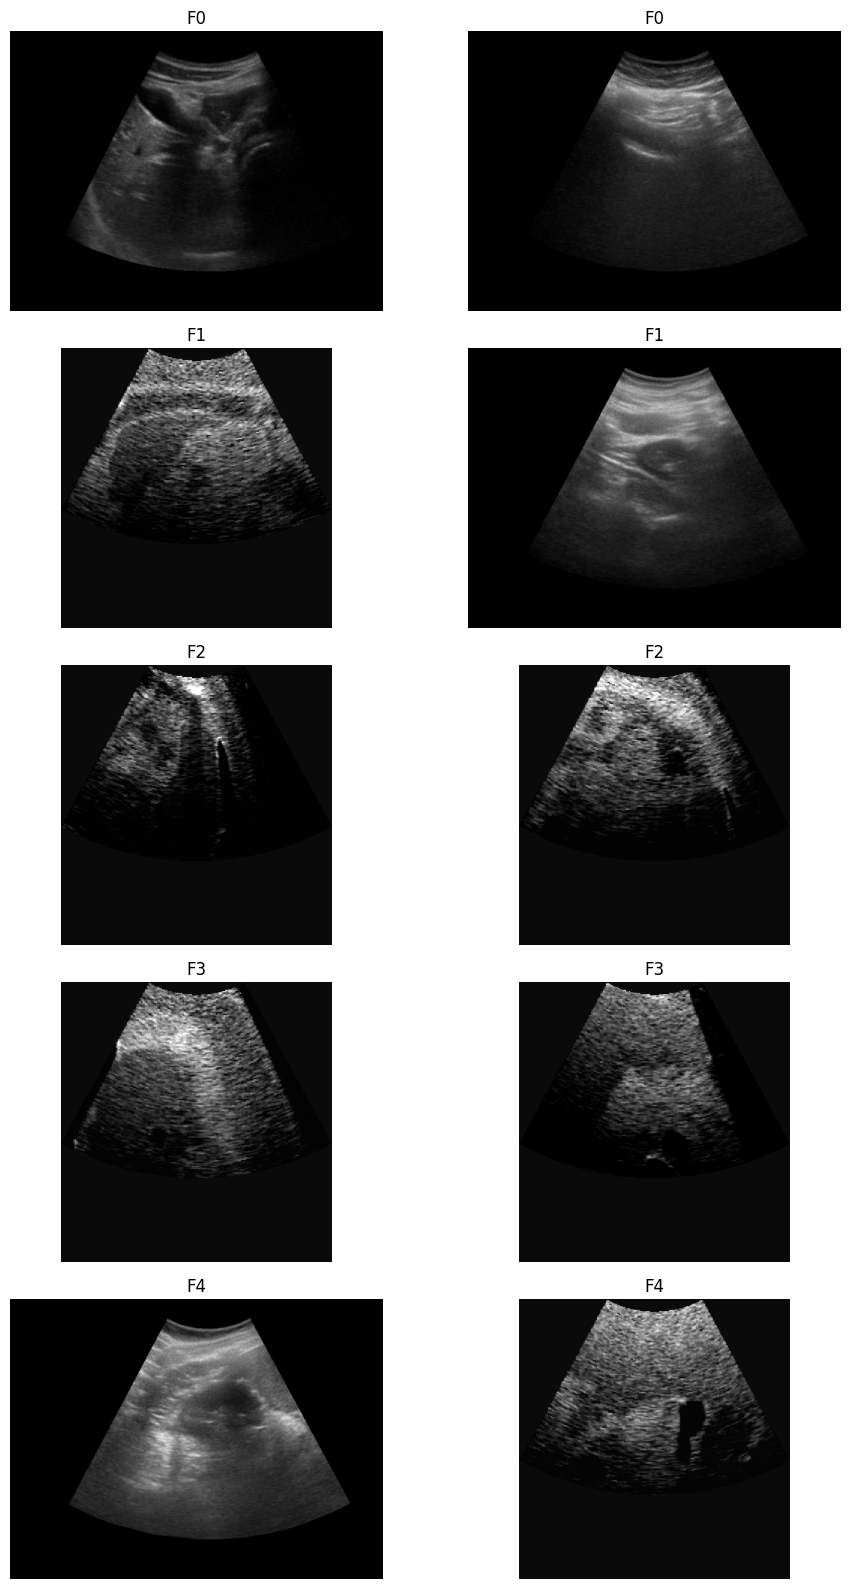

In [7]:
# ============================================================
# STEP 3: VISUALIZE SAMPLE IMAGES FROM ALL 5 CLASSES
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset-এর main folder path
DATASET_PATH = "/content/Dataset/Dataset"

# একই ফলাফল বারবার পাওয়ার জন্য random seed
random.seed(42)

# Dataset-এর class names
classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

# প্রতিটি class থেকে কয়টি image দেখাব
SAMPLES_PER_CLASS = 2

# 5 classes × 2 images = 10 images
fig, axes = plt.subplots(
    len(classes),
    SAMPLES_PER_CLASS,
    figsize=(10, 16)
)

# প্রতিটি class-এর image দেখানো
for row, class_name in enumerate(classes):

    # Current class-এর folder path
    class_path = os.path.join(DATASET_PATH, class_name)

    # Folder-এর image files নির্বাচন
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    # Class-এ image না থাকলে error দেখানো
    if len(image_files) == 0:
        print(f"Warning: No images found in {class_name}")
        continue

    # Available images থেকে 2টি random image নেওয়া
    selected_images = random.sample(
        image_files,
        min(SAMPLES_PER_CLASS, len(image_files))
    )

    # নির্বাচিত image-গুলো display করা
    for col, image_name in enumerate(selected_images):

        # Image-এর complete path
        image_path = os.path.join(class_path, image_name)

        # Image open করে RGB format-এ convert করা
        img = Image.open(image_path).convert("RGB")

        # Image display করা
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

# Layout সুন্দর করা
plt.tight_layout()
plt.show()

# TRAIN AND VALIDATION SPLIT

In [8]:
# ============================================================
# STEP 4: SPLIT EACH CLASS INTO 70% TRAIN AND 30% VALIDATION
# ============================================================

import os
import random
import shutil
import math

# Step 4.1: Original dataset path
SOURCE_DIR = "/content/Dataset/Dataset"

# Step 4.2: New directory for split dataset
OUTPUT_DIR = "/content/Dataset_split"

# Step 4.3: Define split ratio
TRAIN_RATIO = 0.70
VAL_RATIO = 0.30

# Step 4.4: Set random seed for reproducibility
random.seed(42)

# Step 4.5: Supported image formats
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
)

# Step 4.6: Get all class folders
classes = sorted([
    folder for folder in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, folder))
])

# Step 4.7: Create train and validation folders for each class
for class_name in classes:

    source_class_dir = os.path.join(SOURCE_DIR, class_name)

    train_class_dir = os.path.join(
        OUTPUT_DIR, "train", class_name
    )

    val_class_dir = os.path.join(
        OUTPUT_DIR, "val", class_name
    )

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)

    # Collect image filenames
    image_files = [
        file for file in os.listdir(source_class_dir)
        if file.lower().endswith(IMAGE_EXTENSIONS)
        and os.path.isfile(os.path.join(source_class_dir, file))
    ]

    # Shuffle images within this class
    random.shuffle(image_files)

    # Calculate 70% training images
    train_count = math.floor(len(image_files) * TRAIN_RATIO)




    # Split filenames into train and validation
    train_files = image_files[:train_count]
    val_files = image_files[train_count:]

    # Copy training images
    for filename in train_files:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(train_class_dir, filename)
        )

    # Copy validation images
    for filename in val_files:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(val_class_dir, filename)
        )

    # Print split summary for this class
    print(f"\nClass: {class_name}")
    print(f"Total images: {len(image_files)}")
    print(f"Train images: {len(train_files)}")
    print(f"Validation images: {len(val_files)}")

print("\nDataset split completed!")
print("Output directory:", OUTPUT_DIR)


Class: F0
Total images: 2114
Train images: 1479
Validation images: 635

Class: F1
Total images: 861
Train images: 602
Validation images: 259

Class: F2
Total images: 793
Train images: 555
Validation images: 238

Class: F3
Total images: 857
Train images: 599
Validation images: 258

Class: F4
Total images: 1698
Train images: 1188
Validation images: 510

Dataset split completed!
Output directory: /content/Dataset_split


In [9]:
# ============================================================
# STEP 5: MERGE ALL CLASSES INTO TRAIN AND VALIDATION FOLDERS
# ============================================================

import os
import shutil

# Existing split dataset
SOURCE_DIR = "/content/Dataset_split"

# Destination folders
OUTPUT_DIR = "/content/Dataset_merged"

TRAIN_SOURCE = os.path.join(SOURCE_DIR, "train")
VAL_SOURCE = os.path.join(SOURCE_DIR, "val")

TRAIN_DEST = os.path.join(OUTPUT_DIR, "train")
VAL_DEST = os.path.join(OUTPUT_DIR, "val")

# Create destination folders
os.makedirs(TRAIN_DEST, exist_ok=True)
os.makedirs(VAL_DEST, exist_ok=True)

# Supported image extensions
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".webp", ".tif", ".tiff"
)

# Function to merge images from all classes
def merge_classes(source_dir, destination_dir):

    total_images = 0

    # Loop through each class folder
    for class_name in sorted(os.listdir(source_dir)):

        class_dir = os.path.join(source_dir, class_name)

        if not os.path.isdir(class_dir):
            continue

        # Loop through images in the class folder
        for filename in sorted(os.listdir(class_dir)):

            if not filename.lower().endswith(IMAGE_EXTENSIONS):
                continue

            source_path = os.path.join(class_dir, filename)

            # Prefix filename with class name to preserve label
            new_filename = f"{class_name}_{filename}"

            destination_path = os.path.join(
                destination_dir, new_filename
            )

            # Copy image to merged folder
            shutil.copy2(source_path, destination_path)

            total_images += 1

    return total_images


# Merge training images
train_count = merge_classes(TRAIN_SOURCE, TRAIN_DEST)

# Merge validation images
val_count = merge_classes(VAL_SOURCE, VAL_DEST)

# Display results
print("Merge completed successfully!")
print("Merged training images:", train_count)
print("Merged validation images:", val_count)

print("\nOutput structure:")
print(OUTPUT_DIR)
print("  ├── train/  (all training images)")
print("  └── val/    (all validation images)")

Merge completed successfully!
Merged training images: 4423
Merged validation images: 1900

Output structure:
/content/Dataset_merged
  ├── train/  (all training images)
  └── val/    (all validation images)


In [ ]:
TEST_DEST

'/content/Dataset_merged/test'

In [ ]:
TEST_D1 = TEST_DEST

In [ ]:
TEST_D1

'/content/Dataset_merged/test'

#EXTERNAL DATASET

In [10]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!find "/content/drive/MyDrive" -iname "*Liver-Fibrosis*" 2>/dev/null

/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage.v1i.folder.zip


In [31]:
!unzip -q "/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage.v1i.folder.zip" \-d "/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage/"

In [39]:
TEST_DEST = "/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage/test"

In [40]:
import os

total = sum(
    1
    for root, dirs, files in os.walk(TEST_DEST)
    for f in files
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
)

print("Total test images:", total)

Total test images: 161


In [41]:
import os
import shutil

SOURCE_TEST = "/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage/test"
TEST_DEST = "/content/Dataset_merged/test"

os.makedirs(TEST_DEST, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")

total = 0

for class_name in os.listdir(SOURCE_TEST):
    class_path = os.path.join(SOURCE_TEST, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        if filename.lower().endswith(IMAGE_EXTENSIONS):
            source = os.path.join(class_path, filename)

            # class name যোগ করছি যাতে একই filename হলে overwrite না হয়
            new_filename = f"{class_name}_{filename}"
            destination = os.path.join(TEST_DEST, new_filename)

            shutil.copy2(source, destination)
            total += 1

print("Total merged test images:", total)
print("TEST_DEST:", TEST_DEST)

Total merged test images: 161
TEST_DEST: /content/Dataset_merged/test


In [36]:
import os

BASE = "/content/Dataset_merged/test"

for root, dirs, files in os.walk(BASE):
    if "test" in root.lower():
        print(root)

/content/Dataset_merged/test


In [42]:
import os

TEST_DIR = "/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage/test"

for class_name in sorted(os.listdir(TEST_DIR)):
    class_path = os.path.join(TEST_DIR, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")
            )
        ]

        print(class_name, ":", len(images))

F0 : 41
F1 : 30
F2 : 34
F3 : 28
F4 : 28


In [43]:
import shutil
import os

OUTPUT_DIR = "/content/Dataset_final_v2"

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Old Dataset_final_v2 removed.")
print("Fresh output directory created.")

Old Dataset_final_v2 removed.
Fresh output directory created.


#DATA AUGMENTATIONS

In [44]:
# ============================================================
# STEP 7: RESIZE + ALL SELECTED DATA AUGMENTATIONS
# ============================================================

import os
import random
import numpy as np
import torch

from PIL import Image
from torchvision import transforms
from torchvision.transforms import functional as TF

# ------------------------------------------------------------
# 7.1: DEFINE INPUT AND OUTPUT PATHS
# ------------------------------------------------------------

TRAIN_DIR = "/content/Dataset_merged/train"
VAL_DIR = "/content/Dataset_merged/val"
TEST_DIR = "/content/drive/MyDrive/Dataset/Liver-Fibrosis-Stage/test"

OUTPUT_DIR = "/content/Dataset_final_v2"

TRAIN_OUT = os.path.join(OUTPUT_DIR, "train")
VAL_OUT = os.path.join(OUTPUT_DIR, "val")
TEST_OUT = os.path.join(OUTPUT_DIR, "test")

os.makedirs(TRAIN_OUT, exist_ok=True)
os.makedirs(VAL_OUT, exist_ok=True)
os.makedirs(TEST_OUT, exist_ok=True)

# ------------------------------------------------------------
# 7.2: SET RANDOM SEEDS
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# 7.3: DEFINE IMAGE SETTINGS
# ------------------------------------------------------------

TARGET_SIZE = (224, 224)

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".webp", ".tif", ".tiff"
)

# ------------------------------------------------------------
# 7.4: DEFINE GEOMETRIC AND COLOR AUGMENTATIONS
# Applied to training images only
# ------------------------------------------------------------

augmentation = transforms.Compose([

    # Resize all images to 224 x 224
    transforms.Resize(TARGET_SIZE),

    # Random rotation between -20 and +20 degrees
    transforms.RandomRotation(
        degrees=20,
        fill=0
    ),

    # Random horizontal flip with 50% probability
    transforms.RandomHorizontalFlip(p=0.5),

    # Slight brightness and contrast variation
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    # Slight translation and scaling
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        fill=0
    )
])

# ------------------------------------------------------------
# 7.5: PROCESS TRAINING IMAGES
# Save both resized original and augmented copy
# ------------------------------------------------------------

train_files = sorted([
    f for f in os.listdir(TRAIN_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
    and os.path.isfile(os.path.join(TRAIN_DIR, f))
])

original_count = 0
augmented_count = 0

for filename in train_files:

    input_path = os.path.join(TRAIN_DIR, filename)

    try:
        # Open original image
        with Image.open(input_path) as img:
            image = img.convert("RGB")

        # Resize original image without augmentation
        resized_image = image.resize(
            TARGET_SIZE,
            Image.Resampling.LANCZOS
        )

        # Save resized original training image
        original_name, _ = os.path.splitext(filename)

        original_path = os.path.join(
            TRAIN_OUT,
            original_name + ".jpg"
        )

        resized_image.save(original_path, quality=95)
        original_count += 1

        # Apply all selected augmentations
        augmented_image = augmentation(image)

        # Convert to tensor to add slight Gaussian noise
        image_tensor = TF.to_tensor(augmented_image)

        # Gaussian noise with small standard deviation
        noise = torch.randn_like(image_tensor) * 0.01

        # Add noise and keep pixel values in [0, 1]
        noisy_tensor = torch.clamp(
            image_tensor + noise,
            min=0.0,
            max=1.0
        )

        # Convert back to PIL image
        final_augmented = TF.to_pil_image(noisy_tensor)

        # Save one augmented copy
        augmented_path = os.path.join(
            TRAIN_OUT,
            original_name + "_aug1.jpg"
        )

        final_augmented.save(
            augmented_path,
            quality=95
        )

        augmented_count += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# ------------------------------------------------------------
# 7.6: PROCESS VALIDATION IMAGES
# Resize only. No augmentation or noise.
# ------------------------------------------------------------

val_files = sorted([
    f for f in os.listdir(VAL_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
    and os.path.isfile(os.path.join(VAL_DIR, f))
])

val_count = 0

for filename in val_files:

    input_path = os.path.join(
        VAL_DIR,
        filename
    )

    try:
        with Image.open(input_path) as img:
            image = img.convert("RGB")

        # Resize validation image only
        image = image.resize(
            TARGET_SIZE,
            Image.Resampling.LANCZOS
        )

        output_path = os.path.join(
            VAL_OUT,
            os.path.splitext(filename)[0] + ".jpg"
        )

        image.save(
            output_path,
            quality=95
        )

        val_count += 1

    except Exception as e:
        print(
            f"Error processing validation image {filename}: {e}"
        )
# ------------------------------------------------------------
# 7.7: PROCESS TEST IMAGES
# Resize only. No augmentation or noise.
# ------------------------------------------------------------

test_count = 0

for class_name in sorted(os.listdir(TEST_DIR)):

    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    # Keep F0, F1, F2, F3, F4 folders
    output_class_path = os.path.join(
        TEST_OUT,
        class_name
    )

    os.makedirs(output_class_path, exist_ok=True)

    test_files = sorted([
        f for f in os.listdir(class_path)
        if f.lower().endswith(IMAGE_EXTENSIONS)
        and os.path.isfile(os.path.join(class_path, f))
    ])

    for filename in test_files:

        input_path = os.path.join(
            class_path,
            filename
        )

        try:
            with Image.open(input_path) as img:
                image = img.convert("RGB")

            # Resize test image only
            image = image.resize(
                TARGET_SIZE,
                Image.Resampling.LANCZOS
            )

            output_path = os.path.join(
                output_class_path,
                os.path.splitext(filename)[0] + ".jpg"
            )

            image.save(output_path, quality=95)

            test_count += 1

        except Exception as e:
            print(
                f"Error processing test image {filename}: {e}"
            )

# ------------------------------------------------------------
# 7.8: PRINT SUMMARY
# ------------------------------------------------------------

print("\n========== STEP 7 SUMMARY ==========")
print("Target image size:", TARGET_SIZE)
print("Original training images:", original_count)
print("Augmented training images:", augmented_count)
print("Total training images:", original_count + augmented_count)
print("Validation images (resize only):", val_count)
print("External test images (resize only):", test_count)
print("Output directory:", OUTPUT_DIR)
print("====================================")


========== STEP 7 SUMMARY ==========
Target image size: (224, 224)
Original training images: 4423
Augmented training images: 4423
Total training images: 8846
Validation images (resize only): 1900
External test images (resize only): 161
Output directory: /content/Dataset_final_v2


# CREATE LABELS AND PREPARE PYTORCH DATALOADERS

In [45]:
# ============================================================
# STEP 8: CREATE LABELS AND PREPARE PYTORCH DATALOADERS
# ============================================================

import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------
# 8.1: DEFINE DATASET PATHS
# ------------------------------------------------------------

TRAIN_DIR = "/content/Dataset_final_v2/train"
VAL_DIR = "/content/Dataset_final_v2/val"
TEST_DIR = "/content/Dataset_final_v2/test"

# Class names and numeric labels
CLASS_NAMES = ["F0", "F1", "F2", "F3", "F4"]

CLASS_TO_IDX = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

print("Class mapping:", CLASS_TO_IDX)

# ------------------------------------------------------------
# 8.2: DEFINE IMAGE TRANSFORM
# Images are already resized to 224 x 224
# Normalize for pretrained ImageNet models
# ------------------------------------------------------------

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# 8.3: CREATE DATAFRAME
#
# TRAIN:
# Filename prefix identifies class
# Example: F0_image123.jpg -> F0
#
# VALIDATION:
# Filename prefix identifies class
# Example: F0_image123.jpg -> F0
#
# TEST:
# Folder name identifies class
# Example: test/F0/image123.jpg -> F0
# ------------------------------------------------------------

def create_dataframe(folder, data_type):

    records = []

    # --------------------------------------------------------
    # TEST DATA
    # Class is identified by folder name
    # --------------------------------------------------------

    if data_type == "test":

        for class_name in CLASS_NAMES:

            class_folder = os.path.join(
                folder,
                class_name
            )

            if not os.path.isdir(class_folder):
                continue

            for filename in sorted(
                os.listdir(class_folder)
            ):

                if not filename.lower().endswith(
                    (
                        ".jpg",
                        ".jpeg",
                        ".png",
                        ".bmp",
                        ".webp",
                        ".tif",
                        ".tiff"
                    )
                ):
                    continue

                image_path = os.path.join(
                    class_folder,
                    filename
                )

                if not os.path.isfile(image_path):
                    continue

                records.append({
                    "image_path": image_path,
                    "class_name": class_name,
                    "label": CLASS_TO_IDX[class_name]
                })

    # --------------------------------------------------------
    # TRAIN / VALIDATION DATA
    # Images are directly inside folder
    # Class is identified by filename prefix
    # --------------------------------------------------------

    else:

        if not os.path.isdir(folder):
            print("Folder not found:", folder)
            return pd.DataFrame(
                columns=[
                    "image_path",
                    "class_name",
                    "label"
                ]
            )

        for filename in sorted(
            os.listdir(folder)
        ):

            if not filename.lower().endswith(
                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".webp",
                    ".tif",
                    ".tiff"
                )
            ):
                continue

            image_path = os.path.join(
                folder,
                filename
            )

            if not os.path.isfile(image_path):
                continue

            # Extract class from filename
            class_name = filename.split("_", 1)[0]

            if class_name not in CLASS_TO_IDX:
                print(
                    "Skipping unknown class:",
                    filename
                )
                continue

            records.append({
                "image_path": image_path,
                "class_name": class_name,
                "label": CLASS_TO_IDX[class_name]
            })

    return pd.DataFrame(records)


train_df = create_dataframe(
    TRAIN_DIR,
    data_type="train"
)

val_df = create_dataframe(
    VAL_DIR,
    data_type="val"
)

test_df = create_dataframe(
    TEST_DIR,
    data_type="test"
)

# ------------------------------------------------------------
# 8.4: VERIFY CLASS COUNTS
# ------------------------------------------------------------

print("\nTraining image counts:")

if len(train_df) > 0:
    print(
        train_df["class_name"]
        .value_counts()
        .sort_index()
    )
else:
    print("No training images found.")


print("\nValidation image counts:")

if len(val_df) > 0:
    print(
        val_df["class_name"]
        .value_counts()
        .sort_index()
    )
else:
    print("No validation images found.")


print("\nTest image counts:")

if len(test_df) > 0:
    print(
        test_df["class_name"]
        .value_counts()
        .sort_index()
    )
else:
    print("No test images found.")


print("\nTotal training images:", len(train_df))
print("Total validation images:", len(val_df))
print("Total test images:", len(test_df))

# ------------------------------------------------------------
# 8.5: CREATE PYTORCH DATASET
# ------------------------------------------------------------

class UltrasoundDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load image
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        # Apply normalization and tensor conversion
        if self.transform:

            image = self.transform(image)

        # Numeric class label
        label = int(row["label"])

        return image, label


# ------------------------------------------------------------
# 8.6: CREATE DATASET OBJECTS
# ------------------------------------------------------------

train_dataset = UltrasoundDataset(
    train_df,
    transform=image_transform
)

val_dataset = UltrasoundDataset(
    val_df,
    transform=image_transform
)

test_dataset = UltrasoundDataset(
    test_df,
    transform=image_transform
)

# ------------------------------------------------------------
# 8.7: CREATE DATALOADERS
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# 8.8: VERIFY ONE BATCH
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nStep 8 completed successfully!")

Class mapping: {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}

Training image counts:
class_name
F0    2958
F1    1204
F2    1110
F3    1198
F4    2376
Name: count, dtype: int64

Validation image counts:
class_name
F0    635
F1    259
F2    238
F3    258
F4    510
Name: count, dtype: int64

Test image counts:
class_name
F0    41
F1    30
F2    34
F3    28
F4    28
Name: count, dtype: int64

Total training images: 8846
Total validation images: 1900
Total test images: 161

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels: [0, 2, 0, 4, 0, 0, 0, 4, 3, 0]

Training batches: 277
Validation batches: 60
Test batches: 6

Step 8 completed successfully!


#MobileNetV3-Small model setup


In [46]:

# Step 10: MobileNetV3-Small model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import MobileNet_V3_Small_Weights

# GPU available thakle GPU, na hole CPU use korbe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained MobileNetV3-Small load kora
weights = MobileNet_V3_Small_Weights.DEFAULT
model = models.mobilenet_v3_small(weights=weights)

# Final classification layer 5 class-er jonno change kora
num_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_features, 5)

# Model device-e pathano
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.classifier)
print("Model setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 91.2MB/s]

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=5, bias=True)
)
Model setup complete!


In [47]:
!nvidia-smi

Mon Sep 28 11:46:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             26W /   70W |     129MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#MODEL TARING


In [48]:

# Step 11: Train and validate the model

import copy
import torch

num_epochs = 10
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Gradient reset
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Loss and accuracy calculate
        running_train_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    # -------- Validation --------
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

    # Validation loss kom hole best model save kora
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_mobilenetv3_small.pth"
        )

        print("Best model saved!")

# Training seshe best model restore kora
model.load_state_dict(best_model_state)

print("\nTraining complete!")
print("Best validation loss:", round(best_val_loss, 4))
print("Model saved at: /content/best_mobilenetv3_small.pth")


Epoch [1/10]
Train Loss: 0.8966 | Train Accuracy: 0.6187
Val Loss:   0.7468 | Val Accuracy:   0.6868
Best model saved!

Epoch [2/10]
Train Loss: 0.5564 | Train Accuracy: 0.7732
Val Loss:   0.7028 | Val Accuracy:   0.7242
Best model saved!

Epoch [3/10]
Train Loss: 0.3847 | Train Accuracy: 0.8539
Val Loss:   0.5520 | Val Accuracy:   0.7900
Best model saved!

Epoch [4/10]
Train Loss: 0.2633 | Train Accuracy: 0.9052
Val Loss:   0.2274 | Val Accuracy:   0.9200
Best model saved!

Epoch [5/10]
Train Loss: 0.1756 | Train Accuracy: 0.9386
Val Loss:   0.1593 | Val Accuracy:   0.9637
Best model saved!

Epoch [6/10]
Train Loss: 0.1278 | Train Accuracy: 0.9547
Val Loss:   0.4189 | Val Accuracy:   0.8547

Epoch [7/10]
Train Loss: 0.0852 | Train Accuracy: 0.9703
Val Loss:   0.1742 | Val Accuracy:   0.9679

Epoch [8/10]
Train Loss: 0.0604 | Train Accuracy: 0.9786
Val Loss:   0.1914 | Val Accuracy:   0.9379

Epoch [9/10]
Train Loss: 0.0408 | Train Accuracy: 0.9863
Val Loss:   0.1412 | Val Accuracy:  

#EVALUATION

Test Accuracy: 96.27%

Classification Report:
              precision    recall  f1-score   support

          F0     0.9535    1.0000    0.9762        41
          F1     0.9062    0.9667    0.9355        30
          F2     1.0000    0.9412    0.9697        34
          F3     0.9655    1.0000    0.9825        28
          F4     1.0000    0.8929    0.9434        28

    accuracy                         0.9627       161
   macro avg     0.9651    0.9601    0.9614       161
weighted avg     0.9647    0.9627    0.9626       161



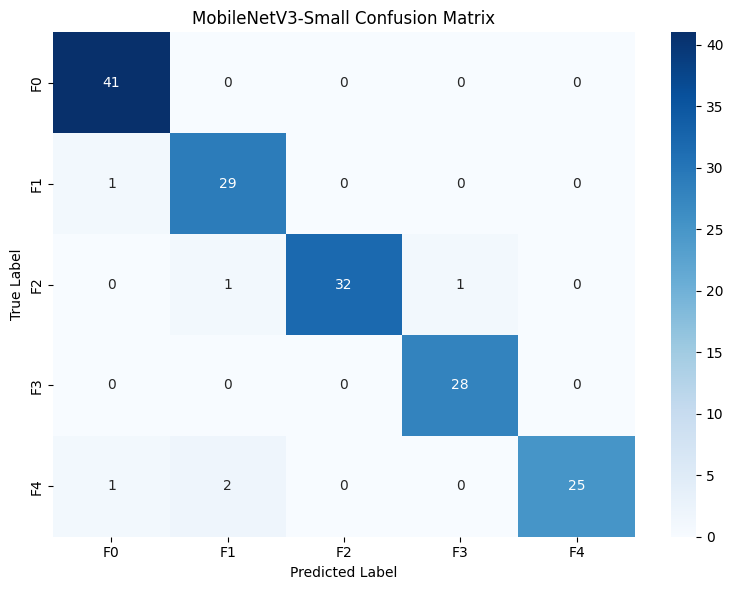

In [49]:

# Step 12: Evaluate the best model on the test dataset

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best saved model load kora
model.load_state_dict(
    torch.load(
        "/content/best_mobilenetv3_small.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

# Class names
class_names = ["F0", "F1", "F2", "F3", "F4"]

all_labels = []
all_predictions = []

# Test set-e prediction
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Overall accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Precision, Recall, F1-score
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV3-Small Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9972
Weighted ROC-AUC: 0.9971


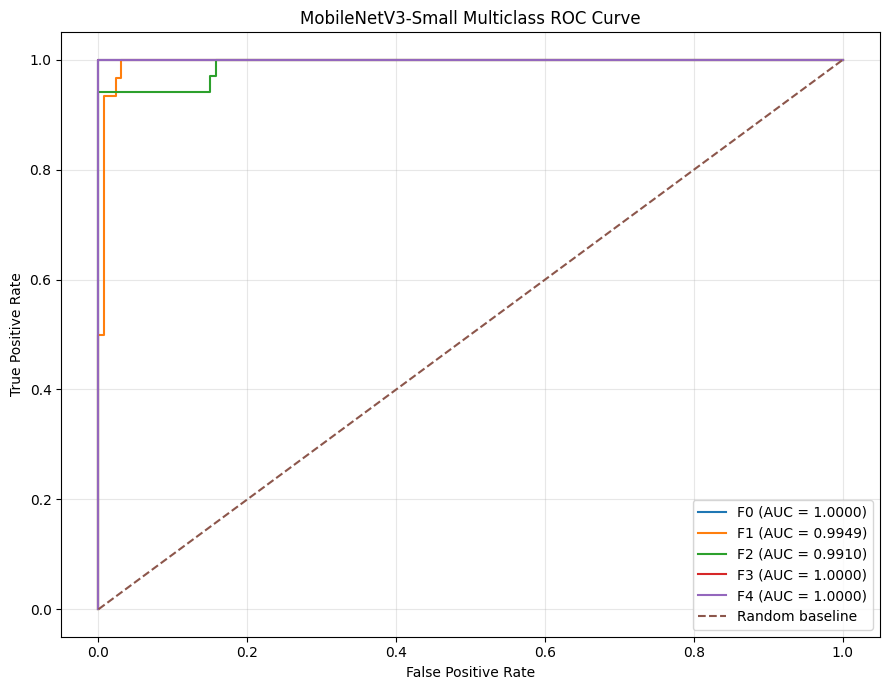

In [50]:

# Step 13: Multiclass ROC Curve and AUC

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

model.eval()

all_labels = []
all_probs = []

# Test set theke predicted probabilities collect kora
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# True labels-ke one-vs-rest binary format-e convert kora
binary_labels = label_binarize(
    all_labels,
    classes=[0, 1, 2, 3, 4]
)

# Macro and weighted multiclass ROC-AUC
macro_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Prottek class-er ROC curve plot kora
plt.figure(figsize=(9, 7))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV3-Small Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

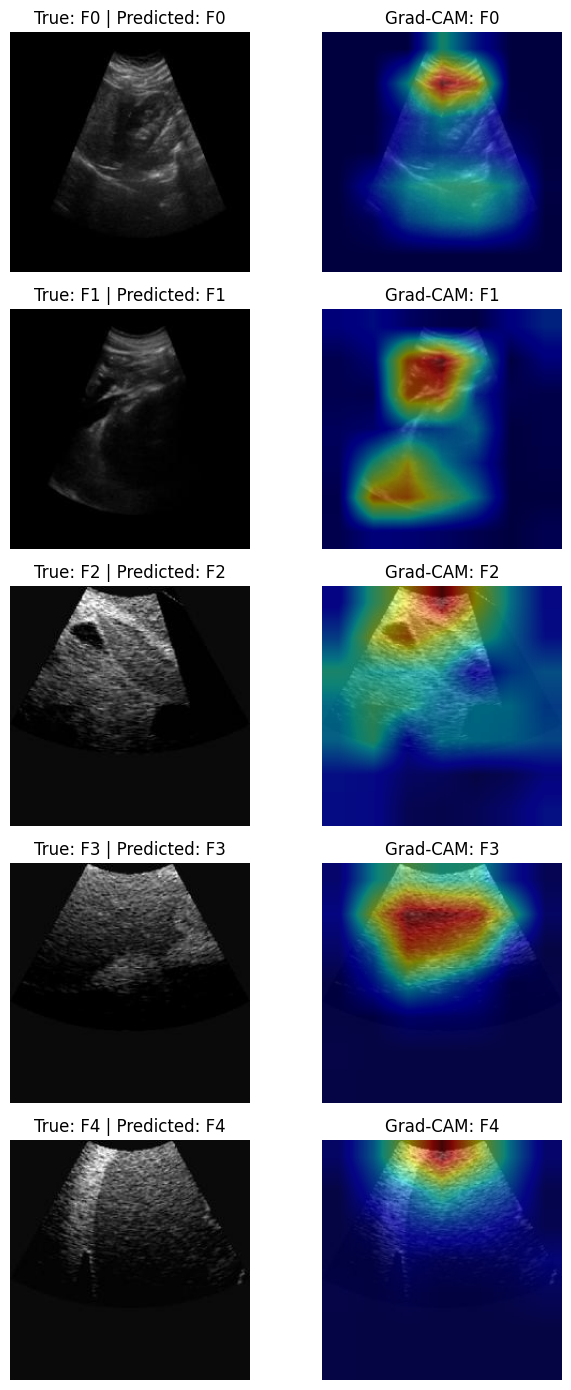


Grad-CAM samples generated:
F0: /content/Dataset_final_v2/test/F0/a1002_jpg.rf.deb32ba597130970de88c5faa58aae56.jpg
F1: /content/Dataset_final_v2/test/F1/A8911_jpg.rf.3dc908497d7faff5c6b863068b9249a5.jpg
F2: /content/Dataset_final_v2/test/F2/I6323_jpg.rf.f07b6e9770317767ef5999a5ff1034b0.jpg
F3: /content/Dataset_final_v2/test/F3/J5910_jpg.rf.7395c96cf11efe1c5a092cd7d5ee5844.jpg
F4: /content/Dataset_final_v2/test/F4/F7280_jpg.rf.8623d06a9e374334f66cb67b7a81dc20.jpg


In [74]:
# Step 19: Research Paper Grad-CAM - MobileNetV3-Small

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms
from torchvision.models import MobileNet_V3_Small_Weights
from torch.nn import functional as F

# ------------------------------------------------------------
# Load MobileNetV3-Small model
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = MobileNet_V3_Small_Weights.DEFAULT

model = models.mobilenet_v3_small(
    weights=weights
)

num_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(
    num_features,
    5
)

# ------------------------------------------------------------
# Load best MobileNetV3-Small checkpoint
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_mobilenetv3_small.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

# ------------------------------------------------------------
# Define Grad-CAM target layer
# ------------------------------------------------------------

target_layer = model.features[-1]

# ------------------------------------------------------------
# Image transform
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Grad-CAM function
# ------------------------------------------------------------

def generate_gradcam(image_path):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = image.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    model.zero_grad()

    output = model(input_tensor)

    predicted_class = torch.argmax(
        output,
        dim=1
    ).item()

    score = output[0, predicted_class]

    score.backward()

    activation = activations[0].detach()
    gradient = gradients[0].detach()

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activation).sum(
        dim=1
    )

    cam = F.relu(cam)

    cam = cam.squeeze().cpu().numpy()

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    cam_image = Image.fromarray(
        np.uint8(cam * 255)
    ).resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    cam = np.array(
        cam_image
    ) / 255.0

    forward_handle.remove()
    backward_handle.remove()

    return (
        original_image,
        cam,
        predicted_class
    )


# ------------------------------------------------------------
# Find one correctly classified image from each class
# ------------------------------------------------------------

correct_samples = {}

for class_name in class_names:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    if not os.path.isdir(class_dir):
        continue

    image_files = sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(
            (
                ".jpg", ".jpeg", ".png",
                ".bmp", ".webp", ".tif", ".tiff"
            )
        )
    ])

    for filename in image_files:

        image_path = os.path.join(
            class_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        input_tensor = transform(
            image
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(
                input_tensor
            )

        predicted_class = torch.argmax(
            output,
            dim=1
        ).item()

        true_class = class_names.index(
            class_name
        )

        if predicted_class == true_class:

            correct_samples[class_name] = image_path

            break


# ------------------------------------------------------------
# Plot Grad-CAM results
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(correct_samples),
    2,
    figsize=(7, 2.8 * len(correct_samples))
)

if len(correct_samples) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )

for row, class_name in enumerate(
    correct_samples.keys()
):

    image_path = correct_samples[
        class_name
    ]

    original_image, cam, predicted_class = generate_gradcam(
        image_path
    )

    # Original image

    axes[row, 0].imshow(
        original_image
    )

    axes[row, 0].axis("off")

    axes[row, 0].set_title(
        f"True: {class_name} | "
        f"Predicted: {class_names[predicted_class]}"
    )

    # Grad-CAM

    axes[row, 1].imshow(
        original_image
    )

    axes[row, 1].imshow(
        cam,
        cmap="jet",
        alpha=0.5
    )

    axes[row, 1].axis("off")

    axes[row, 1].set_title(
        f"Grad-CAM: {class_name}"
    )

plt.tight_layout()
plt.show()

print("\nGrad-CAM samples generated:")

for class_name, path in correct_samples.items():

    print(
        f"{class_name}: {path}"
    )

In [51]:

# Step 14: Save evaluation results

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

class_names = ["F0", "F1", "F2", "F3", "F4"]

# Classification report dictionary
report = classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Classification report CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    "/content/classification_report.csv",
    index=True
)

# Confusion matrix CSV
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

cm_df.to_csv("/content/confusion_matrix.csv")

# AUC results CSV
auc_results = pd.DataFrame({
    "Metric": ["Macro ROC-AUC", "Weighted ROC-AUC"],
    "Score": [macro_auc, weighted_auc]
})

auc_results.to_csv(
    "/content/roc_auc_results.csv",
    index=False
)

print("Evaluation files saved:")
print("/content/classification_report.csv")
print("/content/confusion_matrix.csv")
print("/content/roc_auc_results.csv")

Evaluation files saved:
/content/classification_report.csv
/content/confusion_matrix.csv
/content/roc_auc_results.csv


#ShuffleNetV2 x0.5 model setup

In [52]:

# Step 15: ShuffleNetV2 x0.5 model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ShuffleNet_V2_X0_5_Weights

# GPU or CPU select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained ShuffleNetV2 x0.5 load
weights = ShuffleNet_V2_X0_5_Weights.DEFAULT
model = models.shufflenet_v2_x0_5(weights=weights)

# Final layer 5-class classification-er jonno change
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Model device-e pathano
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.fc)
print("ShuffleNetV2 x0.5 setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


100%|██████████| 5.28M/5.28M [00:00<00:00, 56.5MB/s]

Linear(in_features=1024, out_features=5, bias=True)
ShuffleNetV2 x0.5 setup complete!


#TRAIN ShuffleNetV2 x0.5 model setup

In [53]:

# Step 16: Train and validate ShuffleNetV2 x0.5 mode

import copy
import torch

num_epochs = 20
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # -------- Validation --------
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

    # Best model save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_shufflenet_v2_x0_5.pth"
        )

        print("Best ShuffleNet model saved!")

# Best checkpoint restore
model.load_state_dict(best_model_state)

print("\nShuffleNetV2 training complete!")
print("Best validation loss:", round(best_val_loss, 4))


Epoch [1/20]
Train Loss: 1.3096 | Train Accuracy: 0.4575
Val Loss:   1.0646 | Val Accuracy:   0.5132
Best ShuffleNet model saved!

Epoch [2/20]
Train Loss: 0.9678 | Train Accuracy: 0.5869
Val Loss:   0.7935 | Val Accuracy:   0.6658
Best ShuffleNet model saved!

Epoch [3/20]
Train Loss: 0.7862 | Train Accuracy: 0.6597
Val Loss:   0.6450 | Val Accuracy:   0.7158
Best ShuffleNet model saved!

Epoch [4/20]
Train Loss: 0.6459 | Train Accuracy: 0.7271
Val Loss:   0.5398 | Val Accuracy:   0.7737
Best ShuffleNet model saved!

Epoch [5/20]
Train Loss: 0.5385 | Train Accuracy: 0.7780
Val Loss:   0.4519 | Val Accuracy:   0.8321
Best ShuffleNet model saved!

Epoch [6/20]
Train Loss: 0.4566 | Train Accuracy: 0.8170
Val Loss:   0.3713 | Val Accuracy:   0.8600
Best ShuffleNet model saved!

Epoch [7/20]
Train Loss: 0.4021 | Train Accuracy: 0.8356
Val Loss:   0.3344 | Val Accuracy:   0.8747
Best ShuffleNet model saved!

Epoch [8/20]
Train Loss: 0.3498 | Train Accuracy: 0.8648
Val Loss:   0.2879 | Val 

Test Accuracy: 93.79%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000        41
          F1     0.9062    0.9667    0.9355        30
          F2     0.8571    0.8824    0.8696        34
          F3     0.9259    0.8929    0.9091        28
          F4     1.0000    0.9286    0.9630        28

    accuracy                         0.9379       161
   macro avg     0.9379    0.9341    0.9354       161
weighted avg     0.9395    0.9379    0.9382       161



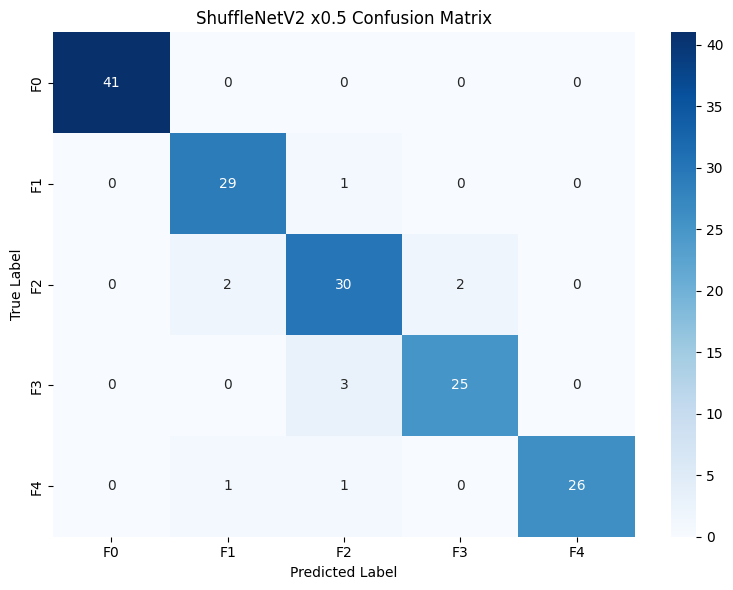

In [59]:
# Step 12: Evaluate the best model on the test dataset

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best saved model load kora
model.load_state_dict(
    torch.load(
        "/content/best_shufflenet_v2_x0_5.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

# Class names
class_names = ["F0", "F1", "F2", "F3", "F4"]

all_labels = []
all_predictions = []

# Test set-e prediction
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Overall accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Precision, Recall, F1-score
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ShuffleNetV2 x0.5 Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9948
Weighted ROC-AUC: 0.9950


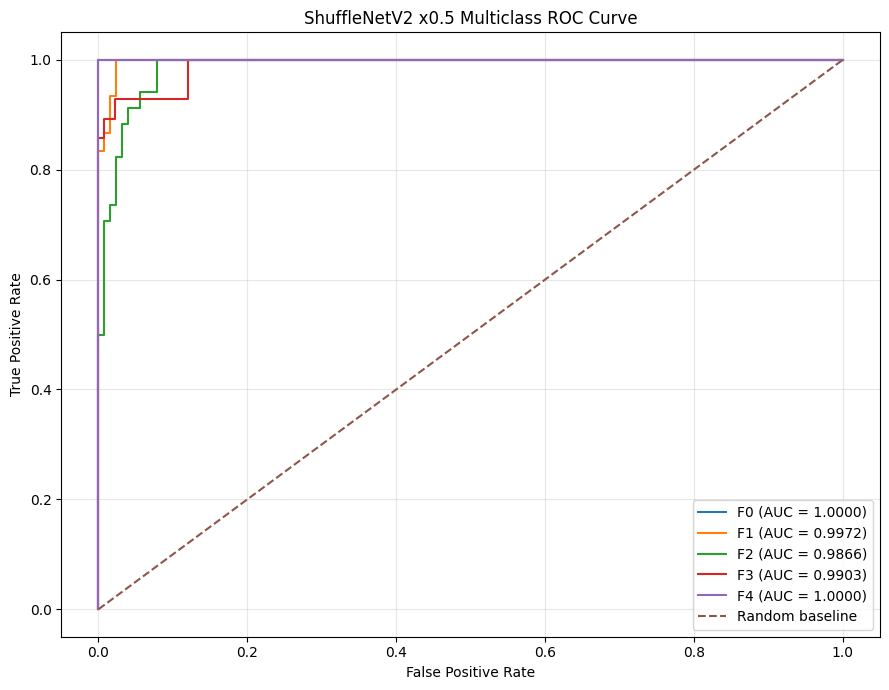

In [60]:
# ============================================================
# STEP 13: Multiclass ROC Curve and AUC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

# Best ShuffleNetV2 x0.5 model load kora
model.load_state_dict(
    torch.load(
        "/content/best_shufflenet_v2_x0_5.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

all_labels = []
all_probs = []

# Test set theke predicted probabilities collect kora
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# True labels-ke one-vs-rest binary format-e convert kora
binary_labels = label_binarize(
    all_labels,
    classes=[0, 1, 2, 3, 4]
)

# Macro and weighted multiclass ROC-AUC
macro_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Prottek class-er ROC curve plot kora
plt.figure(figsize=(9, 7))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ShuffleNetV2 x0.5 Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

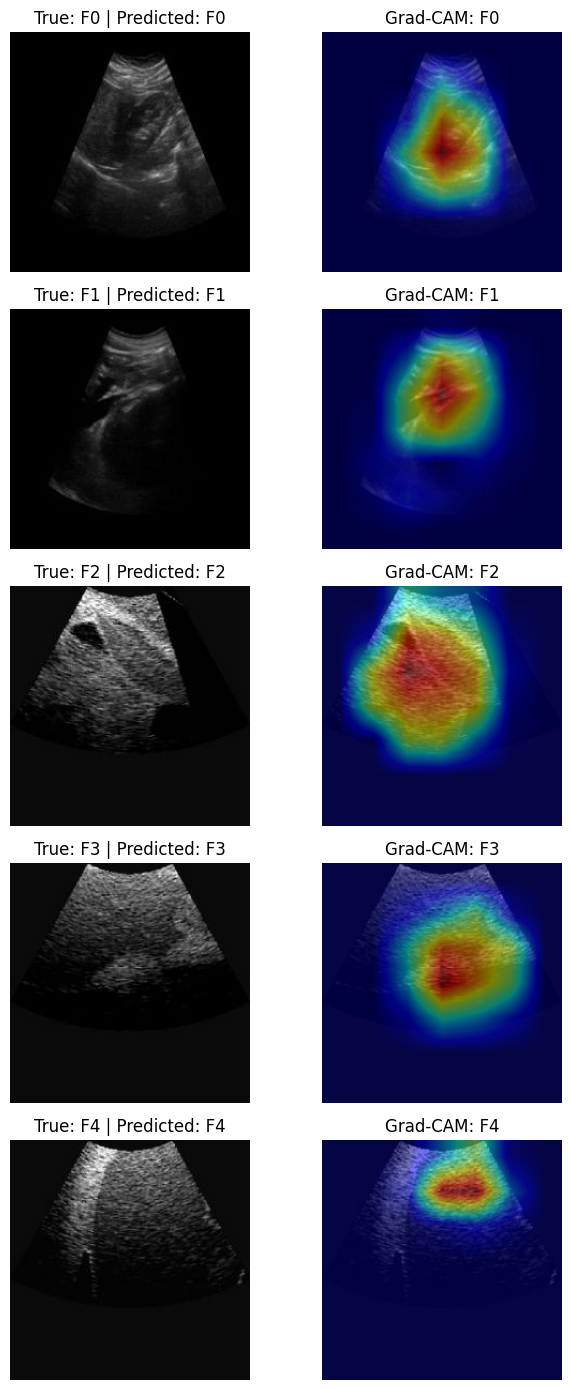


Grad-CAM samples generated:
F0: /content/Dataset_final_v2/test/F0/a1002_jpg.rf.deb32ba597130970de88c5faa58aae56.jpg
F1: /content/Dataset_final_v2/test/F1/A8911_jpg.rf.3dc908497d7faff5c6b863068b9249a5.jpg
F2: /content/Dataset_final_v2/test/F2/I6323_jpg.rf.f07b6e9770317767ef5999a5ff1034b0.jpg
F3: /content/Dataset_final_v2/test/F3/J5910_jpg.rf.7395c96cf11efe1c5a092cd7d5ee5844.jpg
F4: /content/Dataset_final_v2/test/F4/F7280_jpg.rf.8623d06a9e374334f66cb67b7a81dc20.jpg


In [75]:
# Step 20: Research Paper Grad-CAM - ShuffleNetV2 x0.5

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms
from torchvision.models import ShuffleNet_V2_X0_5_Weights
from torch.nn import functional as F

# ------------------------------------------------------------
# Load ShuffleNetV2 x0.5 model
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = ShuffleNet_V2_X0_5_Weights.DEFAULT

model = models.shufflenet_v2_x0_5(
    weights=weights
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    5
)

# ------------------------------------------------------------
# Load best ShuffleNetV2 x0.5 checkpoint
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_shufflenet_v2_x0_5.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

# ------------------------------------------------------------
# Define Grad-CAM target layer
# ------------------------------------------------------------

target_layer = model.conv5

# ------------------------------------------------------------
# Image transform
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Grad-CAM function
# ------------------------------------------------------------

def generate_gradcam(image_path):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = image.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    model.zero_grad()

    output = model(input_tensor)

    predicted_class = torch.argmax(
        output,
        dim=1
    ).item()

    score = output[0, predicted_class]

    score.backward()

    activation = activations[0].detach()
    gradient = gradients[0].detach()

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activation).sum(
        dim=1
    )

    cam = F.relu(cam)

    cam = cam.squeeze().cpu().numpy()

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    cam_image = Image.fromarray(
        np.uint8(cam * 255)
    ).resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    cam = np.array(
        cam_image
    ) / 255.0

    forward_handle.remove()
    backward_handle.remove()

    return (
        original_image,
        cam,
        predicted_class
    )


# ------------------------------------------------------------
# Find one correctly classified image from each class
# ------------------------------------------------------------

correct_samples = {}

for class_name in class_names:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    if not os.path.isdir(class_dir):
        continue

    image_files = sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(
            (
                ".jpg", ".jpeg", ".png",
                ".bmp", ".webp", ".tif", ".tiff"
            )
        )
    ])

    for filename in image_files:

        image_path = os.path.join(
            class_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        input_tensor = transform(
            image
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(
                input_tensor
            )

        predicted_class = torch.argmax(
            output,
            dim=1
        ).item()

        true_class = class_names.index(
            class_name
        )

        if predicted_class == true_class:

            correct_samples[class_name] = image_path

            break


# ------------------------------------------------------------
# Plot Grad-CAM results
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(correct_samples),
    2,
    figsize=(7, 2.8 * len(correct_samples))
)

if len(correct_samples) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )

for row, class_name in enumerate(
    correct_samples.keys()
):

    image_path = correct_samples[
        class_name
    ]

    original_image, cam, predicted_class = generate_gradcam(
        image_path
    )

    # Original image

    axes[row, 0].imshow(
        original_image
    )

    axes[row, 0].axis("off")

    axes[row, 0].set_title(
        f"True: {class_name} | "
        f"Predicted: {class_names[predicted_class]}"
    )

    # Grad-CAM

    axes[row, 1].imshow(
        original_image
    )

    axes[row, 1].imshow(
        cam,
        cmap="jet",
        alpha=0.5
    )

    axes[row, 1].axis("off")

    axes[row, 1].set_title(
        f"Grad-CAM: {class_name}"
    )

plt.tight_layout()
plt.show()

print("\nGrad-CAM samples generated:")

for class_name, path in correct_samples.items():

    print(
        f"{class_name}: {path}"
    )

#SqueezeNet 1.1 model setup

In [61]:
# Step 14: SqueezeNet 1.1 model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import SqueezeNet1_1_Weights

# GPU or CPU select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained SqueezeNet 1.1 load
weights = SqueezeNet1_1_Weights.DEFAULT
model = models.squeezenet1_1(weights=weights)

# Final layer 5-class classification-er jonno change
model.classifier[1] = nn.Conv2d(
    512,
    5,
    kernel_size=1
)

# Dropout same rakha
model.num_classes = 5

# Model device-e pathano
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.classifier)
print("SqueezeNet 1.1 setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 81.2MB/s]

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Conv2d(512, 5, kernel_size=(1, 1), stride=(1, 1))
  (2): ReLU(inplace=True)
  (3): AdaptiveAvgPool2d(output_size=(1, 1))
)
SqueezeNet 1.1 setup complete!


In [62]:
# Step 15: Train and validate SqueezeNet 1.1 model

import copy
import torch

num_epochs = 20
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # -------- Validation --------
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

    # Best model save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_squeezenet1_1.pth"
        )

        print("Best SqueezeNet 1.1 model saved!")

# Best checkpoint restore
model.load_state_dict(best_model_state)

print("\nSqueezeNet 1.1 training complete!")
print("Best validation loss:", round(best_val_loss, 4))


Epoch [1/20]
Train Loss: 0.9127 | Train Accuracy: 0.6039
Val Loss:   0.6644 | Val Accuracy:   0.7516
Best SqueezeNet 1.1 model saved!

Epoch [2/20]
Train Loss: 0.6536 | Train Accuracy: 0.7328
Val Loss:   0.5044 | Val Accuracy:   0.7953
Best SqueezeNet 1.1 model saved!

Epoch [3/20]
Train Loss: 0.5107 | Train Accuracy: 0.7937
Val Loss:   0.3968 | Val Accuracy:   0.8384
Best SqueezeNet 1.1 model saved!

Epoch [4/20]
Train Loss: 0.4319 | Train Accuracy: 0.8276
Val Loss:   0.4005 | Val Accuracy:   0.8337

Epoch [5/20]
Train Loss: 0.3767 | Train Accuracy: 0.8550
Val Loss:   0.3089 | Val Accuracy:   0.8863
Best SqueezeNet 1.1 model saved!

Epoch [6/20]
Train Loss: 0.3285 | Train Accuracy: 0.8724
Val Loss:   0.2592 | Val Accuracy:   0.9100
Best SqueezeNet 1.1 model saved!

Epoch [7/20]
Train Loss: 0.2775 | Train Accuracy: 0.8954
Val Loss:   0.2629 | Val Accuracy:   0.8911

Epoch [8/20]
Train Loss: 0.2438 | Train Accuracy: 0.9085
Val Loss:   0.1994 | Val Accuracy:   0.9258
Best SqueezeNet 1.1

Test Accuracy: 99.38%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000        41
          F1     1.0000    1.0000    1.0000        30
          F2     1.0000    0.9706    0.9851        34
          F3     0.9655    1.0000    0.9825        28
          F4     1.0000    1.0000    1.0000        28

    accuracy                         0.9938       161
   macro avg     0.9931    0.9941    0.9935       161
weighted avg     0.9940    0.9938    0.9938       161



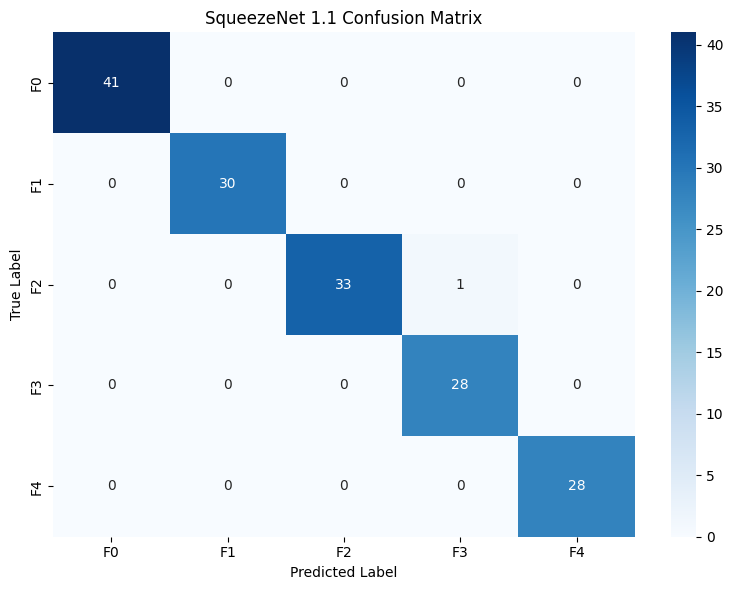

In [63]:
# Step 16: Evaluate the best model on the test dataset

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best saved model load kora
model.load_state_dict(
    torch.load(
        "/content/best_squeezenet1_1.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

# Class names
class_names = ["F0", "F1", "F2", "F3", "F4"]

all_labels = []
all_predictions = []

# Test set-e prediction
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Overall accuracy
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Precision, Recall, F1-score
print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SqueezeNet 1.1 Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9997
Weighted ROC-AUC: 0.9997


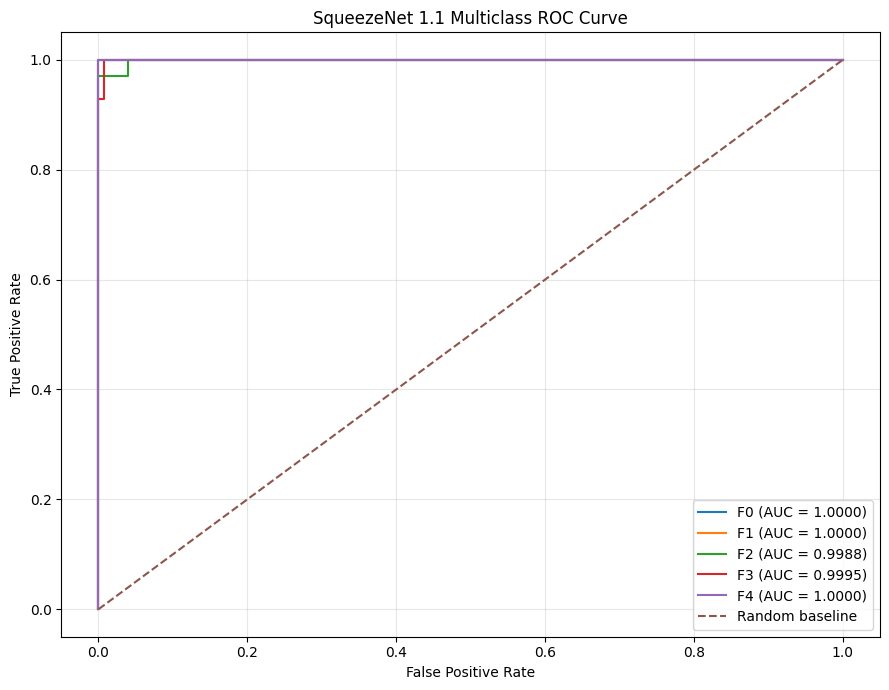

In [64]:
# ============================================================
# STEP 17: Multiclass ROC Curve and AUC - SqueezeNet 1.1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

# ------------------------------------------------------------
# LOAD BEST SQUEEZENET MODEL
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_squeezenet1_1.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

all_labels = []
all_probs = []

# ------------------------------------------------------------
# COLLECT PREDICTED PROBABILITIES
# ------------------------------------------------------------

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ------------------------------------------------------------
# TRUE LABELS -> ONE-VS-REST BINARY FORMAT
# ------------------------------------------------------------

binary_labels = label_binarize(
    all_labels,
    classes=[0, 1, 2, 3, 4]
)

# ------------------------------------------------------------
# MACRO AND WEIGHTED MULTICLASS ROC-AUC
# ------------------------------------------------------------

macro_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# ------------------------------------------------------------
# PLOT ROC CURVES FOR EACH CLASS
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.4f})"
    )

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "SqueezeNet 1.1 Multiclass ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

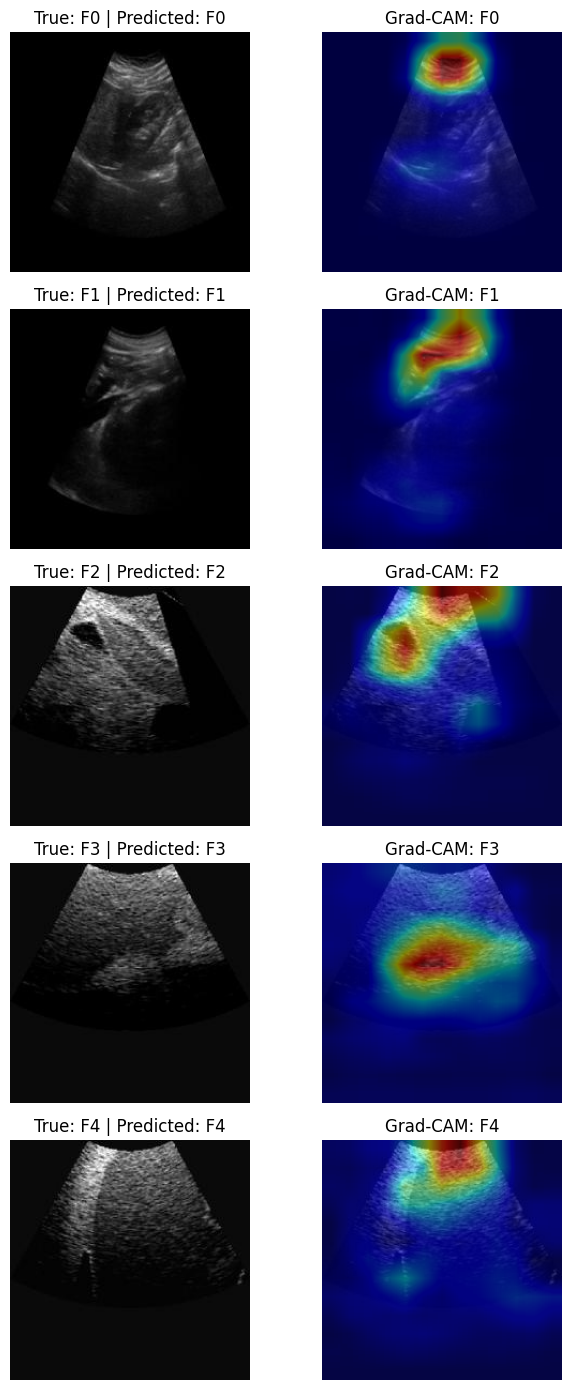


Grad-CAM samples generated:
F0: /content/Dataset_final_v2/test/F0/a1002_jpg.rf.deb32ba597130970de88c5faa58aae56.jpg
F1: /content/Dataset_final_v2/test/F1/A8911_jpg.rf.3dc908497d7faff5c6b863068b9249a5.jpg
F2: /content/Dataset_final_v2/test/F2/I6323_jpg.rf.f07b6e9770317767ef5999a5ff1034b0.jpg
F3: /content/Dataset_final_v2/test/F3/J5910_jpg.rf.7395c96cf11efe1c5a092cd7d5ee5844.jpg
F4: /content/Dataset_final_v2/test/F4/F7280_jpg.rf.8623d06a9e374334f66cb67b7a81dc20.jpg


In [76]:
# Step 21: Research Paper Grad-CAM - SqueezeNet 1.1

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms
from torchvision.models import SqueezeNet1_1_Weights
from torch.nn import functional as F

# ------------------------------------------------------------
# Load SqueezeNet 1.1 model
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = SqueezeNet1_1_Weights.DEFAULT

model = models.squeezenet1_1(
    weights=weights
)

model.classifier[1] = nn.Conv2d(
    512,
    5,
    kernel_size=1
)

model.num_classes = 5

# ------------------------------------------------------------
# Load best SqueezeNet 1.1 checkpoint
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_squeezenet1_1.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

# ------------------------------------------------------------
# Define Grad-CAM target layer
# ------------------------------------------------------------

target_layer = model.features[-1]

# ------------------------------------------------------------
# Image transform
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Grad-CAM function
# ------------------------------------------------------------

def generate_gradcam(image_path):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = image.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    model.zero_grad()

    output = model(input_tensor)

    predicted_class = torch.argmax(
        output,
        dim=1
    ).item()

    score = output[0, predicted_class]

    score.backward()

    activation = activations[0].detach()
    gradient = gradients[0].detach()

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activation).sum(
        dim=1
    )

    cam = F.relu(cam)

    cam = cam.squeeze().cpu().numpy()

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    cam_image = Image.fromarray(
        np.uint8(cam * 255)
    ).resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    cam = np.array(
        cam_image
    ) / 255.0

    forward_handle.remove()
    backward_handle.remove()

    return (
        original_image,
        cam,
        predicted_class
    )


# ------------------------------------------------------------
# Find one correctly classified image from each class
# ------------------------------------------------------------

correct_samples = {}

for class_name in class_names:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    if not os.path.isdir(class_dir):
        continue

    image_files = sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(
            (
                ".jpg", ".jpeg", ".png",
                ".bmp", ".webp", ".tif", ".tiff"
            )
        )
    ])

    for filename in image_files:

        image_path = os.path.join(
            class_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        input_tensor = transform(
            image
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(
                input_tensor
            )

        predicted_class = torch.argmax(
            output,
            dim=1
        ).item()

        true_class = class_names.index(
            class_name
        )

        if predicted_class == true_class:

            correct_samples[class_name] = image_path

            break


# ------------------------------------------------------------
# Plot Grad-CAM results
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(correct_samples),
    2,
    figsize=(7, 2.8 * len(correct_samples))
)

if len(correct_samples) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )

for row, class_name in enumerate(
    correct_samples.keys()
):

    image_path = correct_samples[
        class_name
    ]

    original_image, cam, predicted_class = generate_gradcam(
        image_path
    )

    # Original image

    axes[row, 0].imshow(
        original_image
    )

    axes[row, 0].axis("off")

    axes[row, 0].set_title(
        f"True: {class_name} | "
        f"Predicted: {class_names[predicted_class]}"
    )

    # Grad-CAM

    axes[row, 1].imshow(
        original_image
    )

    axes[row, 1].imshow(
        cam,
        cmap="jet",
        alpha=0.5
    )

    axes[row, 1].axis("off")

    axes[row, 1].set_title(
        f"Grad-CAM: {class_name}"
    )

plt.tight_layout()
plt.show()

print("\nGrad-CAM samples generated:")

for class_name, path in correct_samples.items():

    print(
        f"{class_name}: {path}"
    )

#EfficientNetB0

In [65]:
# Step 15: EfficientNet-B0 model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

# GPU or CPU select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained EfficientNet-B0 load
weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Final layer 5-class classification-er jonno change
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

# Model device-e pathano
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.classifier)
print("EfficientNet-B0 setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 50.2MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)
EfficientNet-B0 setup complete!


#EfficientNetB0 Training

In [66]:
# Step 16: Train and validate EfficientNet-B0 model

import copy
import torch

num_epochs = 20
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # -------- Validation --------
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

    # Best model save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_efficientnet_b0.pth"
        )

        print("Best EfficientNet-B0 model saved!")

# Best checkpoint restore
model.load_state_dict(best_model_state)

print("\nEfficientNet-B0 training complete!")
print("Best validation loss:", round(best_val_loss, 4))


Epoch [1/20]
Train Loss: 0.8157 | Train Accuracy: 0.6606
Val Loss:   0.4250 | Val Accuracy:   0.8353
Best EfficientNet-B0 model saved!

Epoch [2/20]
Train Loss: 0.4212 | Train Accuracy: 0.8362
Val Loss:   0.1910 | Val Accuracy:   0.9263
Best EfficientNet-B0 model saved!

Epoch [3/20]
Train Loss: 0.2580 | Train Accuracy: 0.9061
Val Loss:   0.1311 | Val Accuracy:   0.9579
Best EfficientNet-B0 model saved!

Epoch [4/20]
Train Loss: 0.1485 | Train Accuracy: 0.9473
Val Loss:   0.0974 | Val Accuracy:   0.9747
Best EfficientNet-B0 model saved!

Epoch [5/20]
Train Loss: 0.1059 | Train Accuracy: 0.9633
Val Loss:   0.0739 | Val Accuracy:   0.9821
Best EfficientNet-B0 model saved!

Epoch [6/20]
Train Loss: 0.0780 | Train Accuracy: 0.9729
Val Loss:   0.0659 | Val Accuracy:   0.9832
Best EfficientNet-B0 model saved!

Epoch [7/20]
Train Loss: 0.0619 | Train Accuracy: 0.9785
Val Loss:   0.0873 | Val Accuracy:   0.9758

Epoch [8/20]
Train Loss: 0.0471 | Train Accuracy: 0.9834
Val Loss:   0.0889 | Val

Test Accuracy: 99.38%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000        41
          F1     1.0000    1.0000    1.0000        30
          F2     1.0000    0.9706    0.9851        34
          F3     0.9655    1.0000    0.9825        28
          F4     1.0000    1.0000    1.0000        28

    accuracy                         0.9938       161
   macro avg     0.9931    0.9941    0.9935       161
weighted avg     0.9940    0.9938    0.9938       161



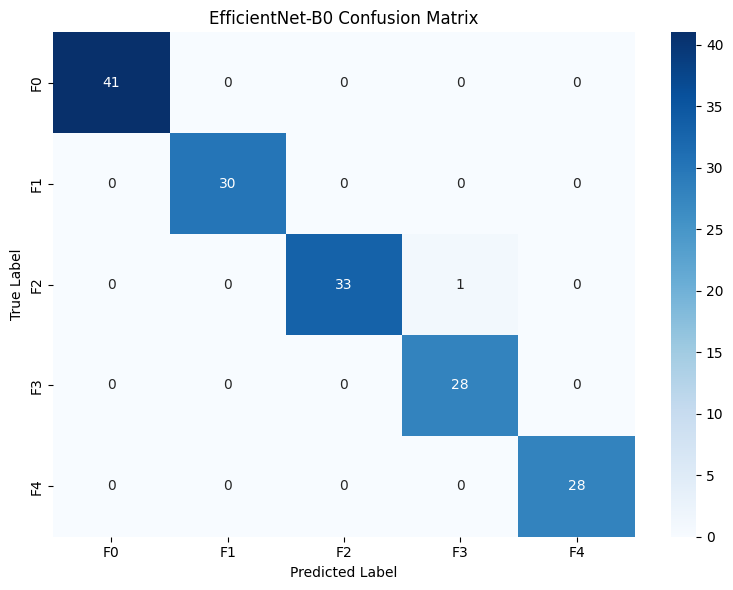

In [68]:
# Step 17: Evaluate the best model on the test dataset

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 Confusion Matrix")

plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9998
Weighted ROC-AUC: 0.9998


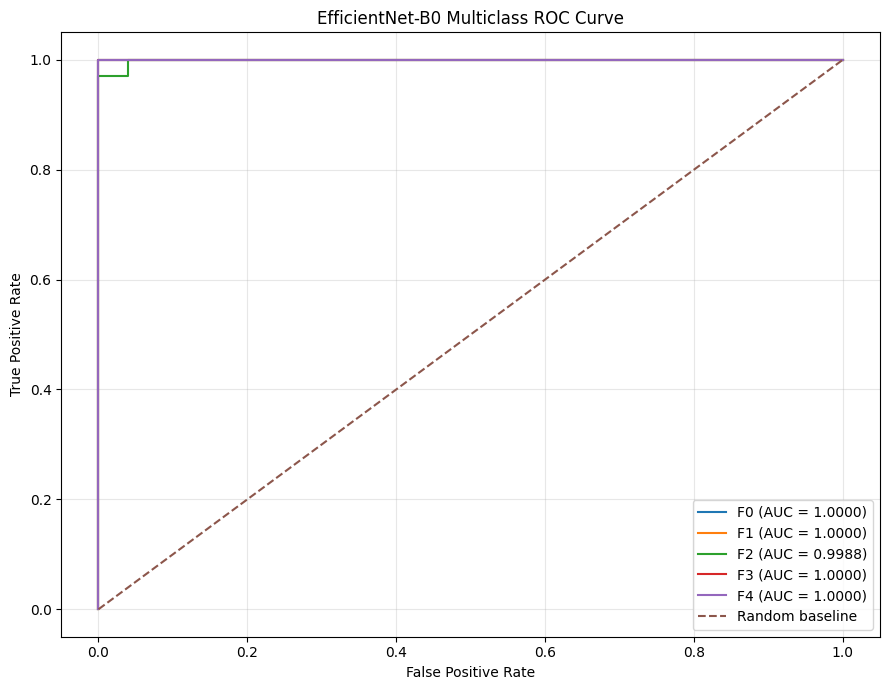

In [69]:
# Step 18: Multiclass ROC Curve and AUC - EfficientNet-B0

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

binary_labels = label_binarize(
    all_labels,
    classes=[0, 1, 2, 3, 4]
)

macro_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

plt.figure(figsize=(9, 7))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "EfficientNet-B0 Multiclass ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

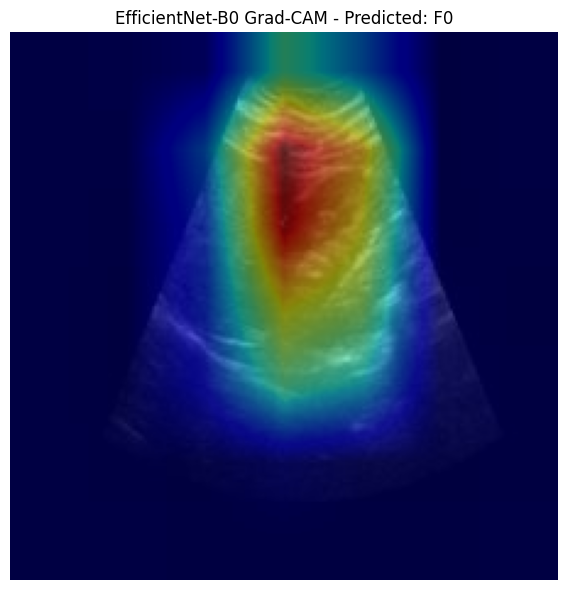

In [70]:
# Step 19: Grad-CAM - EfficientNet-B0

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.nn import functional as F

# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

# ------------------------------------------------------------
# Define Grad-CAM target layer
# ------------------------------------------------------------

target_layer = model.features[-1]

activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# ------------------------------------------------------------
# Select one test image
# ------------------------------------------------------------

image_path = test_df.iloc[0]["image_path"]

image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(image).unsqueeze(0).to(device)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

model.zero_grad()

output = model(input_tensor)

predicted_class = torch.argmax(output, dim=1).item()

# ------------------------------------------------------------
# Backward pass
# ------------------------------------------------------------

score = output[0, predicted_class]
score.backward()

# ------------------------------------------------------------
# Get activations and gradients
# ------------------------------------------------------------

activation = activations[0].detach()
gradient = gradients[0].detach()

weights = gradient.mean(
    dim=(2, 3),
    keepdim=True
)

cam = (weights * activation).sum(dim=1)

cam = F.relu(cam)

cam = cam.squeeze()

cam = cam.cpu().numpy()

# Normalize CAM
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

# ------------------------------------------------------------
# Resize CAM
# ------------------------------------------------------------

cam_image = Image.fromarray(
    np.uint8(cam * 255)
).resize(
    (224, 224),
    Image.Resampling.BILINEAR
)

cam = np.array(cam_image) / 255.0

# ------------------------------------------------------------
# Prepare original image
# ------------------------------------------------------------

original_image = image.resize(
    (224, 224),
    Image.Resampling.LANCZOS
)

# ------------------------------------------------------------
# Display Grad-CAM
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.imshow(original_image)
plt.imshow(
    cam,
    cmap="jet",
    alpha=0.5
)

plt.axis("off")

plt.title(
    f"EfficientNet-B0 Grad-CAM - Predicted: {class_names[predicted_class]}"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Remove hooks
# ------------------------------------------------------------

forward_handle.remove()
backward_handle.remove()

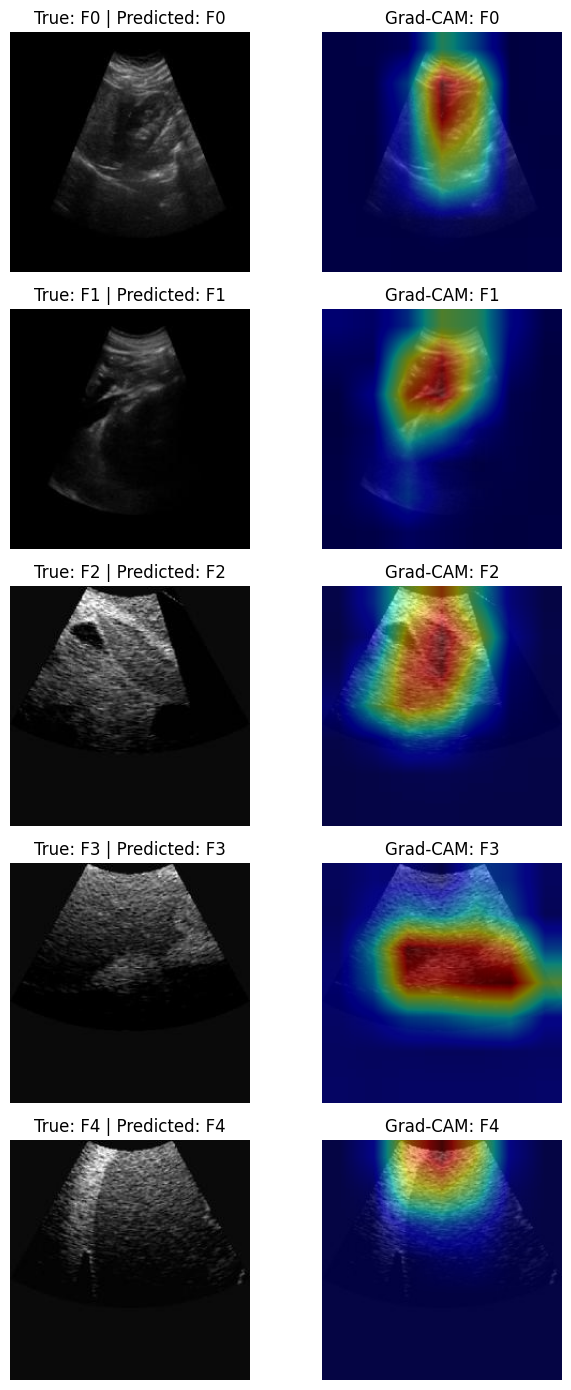


Grad-CAM samples generated:
F0: /content/Dataset_final_v2/test/F0/a1002_jpg.rf.deb32ba597130970de88c5faa58aae56.jpg
F1: /content/Dataset_final_v2/test/F1/A8911_jpg.rf.3dc908497d7faff5c6b863068b9249a5.jpg
F2: /content/Dataset_final_v2/test/F2/I6323_jpg.rf.f07b6e9770317767ef5999a5ff1034b0.jpg
F3: /content/Dataset_final_v2/test/F3/J5910_jpg.rf.7395c96cf11efe1c5a092cd7d5ee5844.jpg
F4: /content/Dataset_final_v2/test/F4/F7280_jpg.rf.8623d06a9e374334f66cb67b7a81dc20.jpg


In [72]:
# Step 19: Research Paper Grad-CAM - EfficientNet-B0

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.nn import functional as F

# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

# ------------------------------------------------------------
# Define Grad-CAM target layer
# ------------------------------------------------------------

target_layer = model.features[-1]

# ------------------------------------------------------------
# Image transform
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Grad-CAM function
# ------------------------------------------------------------

def generate_gradcam(image_path):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    image = Image.open(image_path).convert("RGB")

    original_image = image.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    model.zero_grad()

    output = model(input_tensor)

    predicted_class = torch.argmax(
        output,
        dim=1
    ).item()

    score = output[0, predicted_class]
    score.backward()

    activation = activations[0].detach()
    gradient = gradients[0].detach()

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activation).sum(
        dim=1
    )

    cam = F.relu(cam)

    cam = cam.squeeze().cpu().numpy()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam_image = Image.fromarray(
        np.uint8(cam * 255)
    ).resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    cam = np.array(cam_image) / 255.0

    forward_handle.remove()
    backward_handle.remove()

    return original_image, cam, predicted_class


# ------------------------------------------------------------
# Find one correctly classified image from each class
# ------------------------------------------------------------

correct_samples = {}

for class_name in class_names:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    if not os.path.isdir(class_dir):
        continue

    image_files = sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(
            (
                ".jpg", ".jpeg", ".png",
                ".bmp", ".webp", ".tif", ".tiff"
            )
        )
    ])

    for filename in image_files:

        image_path = os.path.join(
            class_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        input_tensor = transform(
            image
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)

        predicted_class = torch.argmax(
            output,
            dim=1
        ).item()

        true_class = class_names.index(
            class_name
        )

        if predicted_class == true_class:

            correct_samples[class_name] = image_path
            break


# ------------------------------------------------------------
# Plot Grad-CAM results
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(correct_samples),
    2,
    figsize=(7, 2.8 * len(correct_samples))
)

if len(correct_samples) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )

for row, class_name in enumerate(
    correct_samples.keys()
):

    image_path = correct_samples[class_name]

    original_image, cam, predicted_class = generate_gradcam(
        image_path
    )

    # Original image
    axes[row, 0].imshow(
        original_image
    )

    axes[row, 0].axis("off")

    axes[row, 0].set_title(
        f"True: {class_name} | "
        f"Predicted: {class_names[predicted_class]}"
    )

    # Grad-CAM
    axes[row, 1].imshow(
        original_image
    )

    axes[row, 1].imshow(
        cam,
        cmap="jet",
        alpha=0.5
    )

    axes[row, 1].axis("off")

    axes[row, 1].set_title(
        f"Grad-CAM: {class_name}"
    )

plt.tight_layout()
plt.show()

print("\nGrad-CAM samples generated:")

for class_name, path in correct_samples.items():
    print(f"{class_name}: {path}")